# **Programming Practice — Customer Behavior Dataset**

# **Q1. Load the data**

(a) Read customer_behavior_practice.csv into a DataFrame called df.

(b) Print the number of rows and columns.

(c) Show the first 5 rows.

(d) Print each column's data type and identify which columns contain missing values and how many.

In [ ]:
import pandas as pd
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt


uploaded = files.upload()
df= pd.read_csv("/content/customer_behavior_practice.csv")
pd.set_option('display.max_columns', 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

Saving customer_behavior_practice.csv to customer_behavior_practice.csv


In [ ]:
print("Row and Column:",df.shape)

Row and Column: (80, 13)


In [ ]:
print(df.head())

   customer_id  gender      city   age membership  monthly_income  \
0         1001    Male  Rajshahi 53.00    Premium      111,179.00   
1         1002  Female    Khulna 30.00      Basic       58,764.00   
2         1003    Male    Sylhet 49.00      Basic       92,543.00   
3         1004    Male       NaN 24.00    Premium       63,714.00   
4         1005    Male  Rajshahi 39.00   Standard       74,835.00   

   monthly_spending  visits_per_month  satisfaction_score uses_mobile_app  \
0         34,289.00                 6                3.00             Yes   
1         34,024.00                 5                1.00              No   
2         45,675.00                 4                 NaN              No   
3          7,777.00                 2                4.00             Yes   
4         32,749.00                 4                2.00             Yes   

  discount_used  total_purchases  customer_value  
0            No               38       28,508.23  
1            No     

In [ ]:
df.info()

print("\n \n",df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         80 non-null     int64  
 1   gender              80 non-null     object 
 2   city                76 non-null     object 
 3   age                 76 non-null     float64
 4   membership          80 non-null     object 
 5   monthly_income      76 non-null     float64
 6   monthly_spending    76 non-null     float64
 7   visits_per_month    80 non-null     int64  
 8   satisfaction_score  76 non-null     float64
 9   uses_mobile_app     80 non-null     object 
 10  discount_used       80 non-null     object 
 11  total_purchases     80 non-null     int64  
 12  customer_value      80 non-null     float64
dtypes: float64(5), int64(3), object(5)
memory usage: 8.3+ KB

 
 customer_id           0
gender                0
city                  4
age                   4


# **Q2. NumPy practice**
(a) Extract the customer_value and monthly_spending columns as NumPy arrays.

(b) Using NumPy only (not pandas methods), compute the mean, maximum, and minimum of customer_value.

(c) Compute the mean of monthly_spending while ignoring missing values.

(d) Compute the Pearson correlation coefficient between customer_value and monthly_spending, dropping rows where either value is NaN first.

In [ ]:
cValue = df["customer_value"].to_numpy()
print("Max-",np.max(cValue))
print("Min-",np.min(cValue))
print("Mean-",np.mean(cValue))

Max- 39056.32
Min- 6344.24
Mean- 21086.50975


In [ ]:
monthlySpending = df["monthly_spending"]
print("Mean-",np.mean(monthlySpending))
print("Min-",np.min(monthlySpending))
print("Max-",np.max(monthlySpending))

Mean- 24883.32894736842
Min- 3876.0
Max- 49185.0


In [ ]:
print("Ignoring missing value Monthly spending-",np.nanmean(monthlySpending))
print(monthlySpending.isna().sum())

Ignoring missing value Monthly spending- 24883.32894736842
4


In [ ]:
dropingNanvlue = df[["customer_value","monthly_spending"]].dropna()

correlation = dropingNanvlue["customer_value"].corr(dropingNanvlue["monthly_spending"])
print(dropingNanvlue)

    customer_value  monthly_spending
0        28,508.23         34,289.00
1        19,661.80         34,024.00
2        32,335.49         45,675.00
3        13,937.76          7,777.00
4        29,540.32         32,749.00
..             ...               ...
75       20,732.54         29,211.00
76       33,350.94         40,220.00
77       26,297.55         29,646.00
78       36,918.15         41,649.00
79       18,174.65         26,049.00

[76 rows x 2 columns]


# **Q3. DataFrame selection and filtering**
(a) Select rows 10–19 and the columns in positions 2, 3, 4, and 12.

(b) Show the customer_id, city, membership, and customer_value columns for the first 8 customers.

(c) Show all Premium members in Dhaka whose satisfaction_score > 7.

(d) Count how many customers use a discount and have customer_value < 15000.

In [ ]:
print(df.iloc[10:20,[2,3,4,12]])

          city   age membership  customer_value
10      Khulna 45.00    Premium        6,344.24
11  Chittagong 37.00    Premium       17,787.17
12  Chittagong 47.00   Standard       26,355.11
13    Rajshahi 28.00   Standard        7,793.96
14  Chittagong 45.00    Premium       30,372.86
15  Chittagong 42.00    Premium       10,462.82
16    Rajshahi 56.00   Standard       12,067.64
17    Rajshahi 50.00      Basic       19,507.81
18       Dhaka 18.00      Basic       18,364.87
19      Khulna 44.00   Standard       19,244.66


In [ ]:
print(df.loc[:8 , ["customer_id","city","customer_value"],])

   customer_id        city  customer_value
0         1001    Rajshahi       28,508.23
1         1002      Khulna       19,661.80
2         1003      Sylhet       32,335.49
3         1004         NaN       13,937.76
4         1005    Rajshahi       29,540.32
5         1006  Chittagong       14,508.68
6         1007    Rajshahi        8,068.98
7         1008  Chittagong       19,586.15
8         1009  Chittagong       16,121.66


In [ ]:
premium_members = df[df["satisfaction_score"]>7]
print("Premium_member:",premium_members.head())

Premium_member:     customer_id  gender        city   age membership  monthly_income  \
7          1008    Male  Chittagong 59.00      Basic       36,589.00   
13         1014    Male    Rajshahi 28.00   Standard       50,635.00   
19         1020    Male      Khulna 44.00   Standard       18,301.00   
24         1025  Female       Dhaka 23.00    Premium       28,492.00   
26         1027  Female    Rajshahi 44.00      Basic             NaN   

    monthly_spending  visits_per_month  satisfaction_score uses_mobile_app  \
7          30,236.00                 3                8.00             Yes   
13          3,876.00                 4                9.00              No   
19         10,987.00                11                9.00             Yes   
24         49,185.00                 3                9.00              No   
26         29,258.00                 1                9.00             Yes   

   discount_used  total_purchases  customer_value  
7             No              

In [ ]:
disCount  = df[(df["discount_used"] == "Yes") &
               (df["customer_value"]<15000)]

print("Discount customer over 15000 are-",disCount)

Discount customer over 15000 are-     customer_id  gender        city   age membership  monthly_income  \
15         1016    Male  Chittagong 42.00    Premium             NaN   
29         1030  Female       Dhaka 50.00    Premium       44,641.00   
30         1031    Male      Khulna 59.00    Premium       52,584.00   
61         1062    Male      Sylhet 41.00   Standard       88,316.00   
62         1063    Male       Dhaka 22.00    Premium       20,368.00   
64         1065    Male  Chittagong 23.00   Standard       24,655.00   
68         1069  Female  Chittagong 50.00      Basic      105,922.00   

    monthly_spending  visits_per_month  satisfaction_score uses_mobile_app  \
15          7,142.00                 7                 NaN              No   
29         20,214.00                 3                3.00             Yes   
30         17,098.00                11               10.00              No   
61         10,253.00                 7               10.00             Yes   

# **Q4. Explore the data with aggregation and visualisation**

(a) Find the average customer_value and average monthly_spending per membership, sorted by average customer_value descending.

(b) Count customers by city and by membership. Which city has the most customers?

(c) Draw a bar chart of average customer_value per membership, and a histogram of customer_value with 15 bins.


In [ ]:
avg = df.groupby("membership")[["customer_value","monthly_spending"]].mean()

avg = avg.sort_values( by="customer_value", ascending=False)
print(avg)

            customer_value  monthly_spending
membership                                  
Basic            22,189.26         27,832.29
Standard         20,698.23         23,453.50
Premium          20,211.13         22,872.71


In [ ]:
mostCustomers = df.groupby(["city","membership"]).size()
print(mostCustomers)

city        membership
Chittagong  Basic         6
            Premium       3
            Standard      6
Dhaka       Basic         8
            Premium       5
            Standard      3
Khulna      Basic         6
            Premium       4
            Standard      5
Rajshahi    Basic         3
            Premium       6
            Standard      7
Sylhet      Basic         5
            Premium       5
            Standard      4
dtype: int64


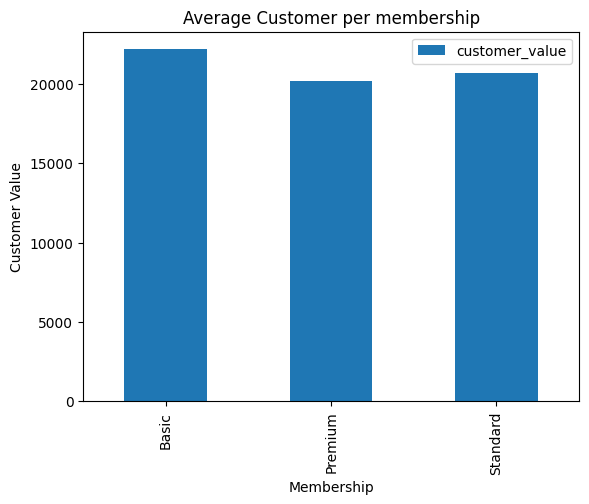

In [ ]:
chart = df.groupby("membership")[["customer_value"]].mean()
chart.plot(kind="bar")
plt.title("Average Customer per membership")
plt.xlabel("Membership")
plt.ylabel("Customer Value")
plt.show()

# **Part B — Data Preprocessing**


# **Q5. Train/test split Before any preprocessing, split the data. Use customer_value as the target (y) and all other columns except customer_id as features (X).**

(a) Create X_train, X_test, y_train, y_test with a 75/25 split and random_state=42.

(b) Print the size of each split and confirm the shapes are as expected.



In [ ]:
#We use this to split our dataset into training data and testing data.
from sklearn.model_selection import train_test_split

In [ ]:
x = df.drop(columns=["customer_id","customer_value"])
y = df["customer_value"]
print("x shape:",x.shape)
print("y shape:",y.shape)

x shape: (80, 11)
y shape: (80,)


In [ ]:
train_x, test_x, train_y, test_y = train_test_split(
    x,y, test_size=0.25, random_state=42)

print("Train_x shape:",train_x.shape)
print("Test_x shape:",test_x.shape)
print("Train_y shape:",train_y.shape)
print("Test_y shape:",test_y.shape)

Train_x shape: (60, 11)
Test_x shape: (20, 11)
Train_y shape: (60,)
Test_y shape: (20,)


# **Q6. Handle missing numeric values**
(a) For the numeric columns with missing values (age, monthly_income monthly_spending, satisfaction_score), use SimpleImputer(strategy='median').

(b) Fit the imputer on X_train only. Transform both X_train and X_test.

(c) Confirm that neither split has missing values after imputation.



In [ ]:
#We use SimpleImputer to handle missing values (NaN) in a dataset.
from sklearn.impute import SimpleImputer

In [ ]:
numaric_columns = ["age","monthly_income","monthly_spending","satisfaction_score", "visits_per_month",
    "total_purchases"]
imputer = SimpleImputer(strategy="median")
train_x[numaric_columns] = imputer.fit_transform(train_x[numaric_columns])
test_x[numaric_columns] = imputer.transform(test_x[numaric_columns])


In [ ]:
print("Train_x shape:\n",train_x.isnull().sum())
print("\nTest_x shape:\n",test_x.isnull().sum())

Train_x shape:
 gender                0
city                  4
age                   0
membership            0
monthly_income        0
monthly_spending      0
visits_per_month      0
satisfaction_score    0
uses_mobile_app       0
discount_used         0
total_purchases       0
dtype: int64

Test_x shape:
 gender                0
city                  0
age                   0
membership            0
monthly_income        0
monthly_spending      0
visits_per_month      0
satisfaction_score    0
uses_mobile_app       0
discount_used         0
total_purchases       0
dtype: int64


# **Q7. Encode categorical columns**
(a) Apply OneHotEncoder(drop='first', sparse_output=False) to gender, city, membership, uses_mobile_app, discount_used. Fit on train and transform both splits.

(b) Explain what happens when a categorical column has more than two categories, such as membership or city.

(c) What would happen if a new city appears during testing that was not present during training? Explain how handle_unknown='ignore' can help.

In [ ]:
#We use OneHotEncoder to convert categorical (text) values into numbers so a machine-learning model can understand them.
from sklearn.preprocessing import OneHotEncoder

In [ ]:
string_value = ["gender","city","membership","uses_mobile_app","discount_used"]
encoder = OneHotEncoder(drop="first",sparse_output=False)
train_encoder = encoder.fit_transform(train_x[string_value])
test_encoder = encoder.transform(test_x[string_value])

In [ ]:
#string_value = ["gender","city","membership","uses_mobile_app","discount_used"]
#encoder = OneHotEncoder(drop="first",sparse_output=False, handel_unknown = 'ignore')
#train_encoder = encoder.fit_transform(train_x[string_value])
#test_encoder = encoder.transform(test_x[string_value])

# **Q8. Scale numeric features**

(a) Apply StandardScaler() to the numeric feature columns: age, monthly_income, monthly_spending, visits_per_month, satisfaction_score, total_purchases.

(b) Fit on X_train only. Transform both splits.

(c) Verify that the scaled training data has mean » 0 and std » 1. Print both.


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:

numValue = ["age","monthly_income","monthly_spending","visits_per_month","satisfaction_score","total_purchases"]
scaler = StandardScaler()
train_x[numValue] = scaler.fit_transform(train_x[numValue])
test_x[numValue] = scaler.transform(test_x[numValue])

In [ ]:
print("Mean:", trainProcess.mean(axis=0))
print("Std:", trainProcess.std(axis=0))

Mean: [ 4.20959564e-17 -2.96059473e-17 -6.66133815e-17 -1.07321559e-16
 -1.11022302e-17  3.88578059e-17  4.66666667e-01  2.00000000e-01
  1.50000000e-01  2.00000000e-01  2.00000000e-01  6.66666667e-02
  3.00000000e-01  2.83333333e-01  4.83333333e-01  5.33333333e-01]
Std: [1.         1.         1.         1.         1.         1.
 0.49888765 0.4        0.35707142 0.4        0.4        0.24944383
 0.45825757 0.45061686 0.49972215 0.49888765]


# **Q9. Build a complete preprocessing pipeline**
(a) Build a ColumnTransformer that applies SimpleImputer + StandardScaler to the four numeric columns with missing values, and OneHotEncoder to the categorical columns.

(b) Wrap the ColumnTransformer in a Pipeline. Fit it on X_train and transform both X_train and X_test.

(c) Print the shape of the transformed training and test matrices.



In [ ]:
from sklearn.pipeline import Pipeline

numarical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

catagory_pipeline = Pipeline([
    ("encoder",OneHotEncoder(drop="first",sparse_output=False)),
    ("imputer",SimpleImputer(strategy="most_frequent"))
])




In [ ]:
from sklearn.compose import ColumnTransformer
process = ColumnTransformer([
    ("numarical",numarical_pipeline,numaric_columns),
    ("catagory",catagory_pipeline,string_value)
])

In [ ]:
trainProcess = process.fit_transform(train_x)
testProcess = process.transform(test_x)

print("Train_x shape:",trainProcess.shape)
print("Test_x shape:",testProcess.shape)

Train_x shape: (60, 16)
Test_x shape: (20, 16)


In [ ]:
process.get_feature_names_out()

array(['numarical__age', 'numarical__monthly_income',
       'numarical__monthly_spending', 'numarical__satisfaction_score',
       'numarical__visits_per_month', 'numarical__total_purchases',
       'catagory__gender_Male', 'catagory__city_Dhaka',
       'catagory__city_Khulna', 'catagory__city_Rajshahi',
       'catagory__city_Sylhet', 'catagory__city_nan',
       'catagory__membership_Premium', 'catagory__membership_Standard',
       'catagory__uses_mobile_app_Yes', 'catagory__discount_used_Yes'],
      dtype=object)